# SBA 7(a) Loan Default Prediction (FY2020–Present)

This notebook implements a complete machine learning workflow to predict loan default using SBA 7(a) loan data (FY2020–present). The pipeline includes data preparation, supervised modeling, class-imbalance handling (SMOTE), model interpretation, and exploratory unsupervised clustering.

## Dataset Source (data.gov)

The dataset used in this project is the SBA 7(a) FOIA dataset (FY2020–Present), retrieved from **data.gov**.  
File used in this notebook: `foia-7a-fy2020-present-asof-250930.csv` (download snapshot).

It contains loan-level attributes available at/near approval time and loan outcome statuses.

**Supervised target definition:**
- Default (1): `LoanStatus = CHGOFF`
- Non-default (0): `LoanStatus = PIF`

To ensure a clean, unambiguous supervised label, the supervised dataset keeps only loans with final outcomes (PIF/CHGOFF) and excludes other statuses (e.g., COMMIT/CANCLD/EXEMPT) that may represent incomplete, pending, or non-comparable outcomes.

## 1. Imports and Global Configuration

All imports and global settings are centralized to keep the notebook readable, maintainable, and reproducible.

In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.dummy import DummyClassifier

from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    silhouette_score,
    precision_recall_curve,
)

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.cluster import KMeans

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load Data

The dataset is loaded from a local CSV file. A quick sanity check is performed by printing the dataset shape and previewing the first rows.

In [6]:
DATA_PATH = Path("foia-7a-fy2020-present-asof-250930 (1).csv")  # update if needed

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"CSV file not found: {DATA_PATH.resolve()}\n"
        "Please place the file in the notebook directory or update DATA_PATH."
    )

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Dataset shape: (347514, 43)


,AsOfDate,Program,BorrName,BorrStreet,BorrCity,BorrState,BorrZip,LocationID,BankName,BankFDICNumber,...,BusinessType,BusinessAge,LoanStatus,PaidinFullDate,ChargeoffDate,GrossChargeoffAmount,RevolverStatus,JobsSupported,CollateralInd,SoldSecondMarketInd
0,2025-09-30,7A,MID-KAM CRUSHING LLC,9000 Aetna Rd,Cleveland,OH,44105,57328.0,The Huntington National Bank,6560.0,...,CORPORATION,Existing or more than 2 years old,CANCLD,NaN,NaN,0.0,0,4.0,N,NaN
1,2025-09-30,7A,Yeadam,1428 CONTRA COSTA BLVD,PLEASANT HILL,CA,94523,433106.0,Poppy Bank,57903.0,...,CORPORATION,Existing or more than 2 years old,PIF,06/30/2023,NaN,0.0,0,12.0,Y,NaN
2,2025-09-30,7A,Dreadnought Brewing LLC,16726 146TH ST SE STE 153,MONROE,WA,98272,59698.0,Columbia Bank,17266.0,...,CORPORATION,Existing or more than 2 years old,EXEMPT,NaN,NaN,0.0,1,0.0,N,NaN
3,2025-09-30,7A,Big Oaks Golf Course LLC,3451 Big Oaks Golf Course,Saltillo,MS,38866,39848.0,Cadence Bank,11813.0,...,CORPORATION,"Startup, Loan Funds will Open Business",CANCLD,NaN,NaN,0.0,0,12.0,Y,NaN
4,2025-09-30,7A,Stillpoint Therapies LLC,"2469 Earl Campbell Parkway, Su",Tyler,TX,75701,70468.0,"Austin Bank, Texas National Association",3276.0,...,CORPORATION,"Startup, Loan Funds will Open Business",EXEMPT,NaN,NaN,0.0,0,5.0,Y,NaN


## 3. Target Definition

A binary target `LoanDefault` is defined using unambiguous loan outcomes:
- `CHGOFF` (charged off) → default (`1`)
- `PIF` (paid in full) → non-default (`0`)

To reduce label ambiguity, supervised modeling is restricted to these two statuses. The resulting target distribution is inspected to quantify class imbalance.

In [8]:
# Standardize status values to avoid issues with casing/whitespace
df_raw["LoanStatus"] = df_raw["LoanStatus"].astype(str).str.strip().str.upper()

# Keep only clear outcomes for supervised learning
df_model = df_raw[df_raw["LoanStatus"].isin(["PIF", "CHGOFF"])].copy()

# Binary target: 1=default, 0=non-default
df_model["LoanDefault"] = (df_model["LoanStatus"] == "CHGOFF").astype(int)

# Sanity checks and class distribution
counts = df_model["LoanDefault"].value_counts().sort_index()
props = df_model["LoanDefault"].value_counts(normalize=True).sort_index()

print("Modeling subset shape:", df_model.shape)
print("\nClass counts:\n", counts.rename({0: "non-default (0)", 1: "default (1)"}))
print("\nClass proportions:\n", props.rename({0: "non-default (0)", 1: "default (1)"}))

assert set(df_model["LoanDefault"].unique()) == {0, 1}, "Unexpected target values detected."

Modeling subset shape: (55954, 44)

Class counts:
 LoanDefault
non-default (0)    51791
default (1)         4163
Name: count, dtype: int64

Class proportions:
 LoanDefault
non-default (0)    0.9256
default (1)        0.0744
Name: proportion, dtype: float64


The target is imbalanced: defaults represent ~7.4% of the modeling subset. This motivates the use of imbalance-aware evaluation (e.g., ROC-AUC/PR-AUC) and class-balancing techniques such as SMOTE later in the workflow.

## 4. Data Cleaning for Modeling

To prepare the dataset for supervised modeling, text-heavy identifiers and leakage-prone fields are removed.
In particular, any columns that reflect the final outcome (e.g., payoff/charge-off dates and amounts, or the original status label used to define the target) are excluded to prevent target leakage.

A compact industry-sector feature (`NAICS2`) is engineered from `NAICSCode` by keeping the 2-digit prefix (sector level).
Missing values are intentionally handled later inside the preprocessing pipelines (imputation + encoding + scaling) to avoid leakage across train/test splits.

**Target leakage prevention:**  
All fields that directly encode the outcome or become known only after the outcome are removed from the feature set.
Examples include: `PaidinFullDate`, `ChargeoffDate`, and `GrossChargeoffAmount`.
In addition, the original `LoanStatus` column is removed after defining the target, since it is the source label.

In [11]:
cols_to_drop = [
    "BorrName","BorrStreet","BorrCity",
    "BankName","BankStreet","BankCity",
    "FranchiseName","FranchiseCode",
    "PaidinFullDate","ChargeoffDate","GrossChargeoffAmount",
    "BankNCUANumber",
    "LoanStatus",        # leakage source (used to define the target)
    "NAICSDescription"   # high-cardinality text; NAICS2 keeps the signal
]

df_model_clean = df_model.drop(columns=cols_to_drop, errors="ignore").reset_index(drop=True)

# NAICS: keep a 2-digit sector code as categorical signal (sector-level)
df_model_clean["NAICS2"] = df_model_clean["NAICSCode"].astype(str).str.zfill(6).str[:2]

df_model_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55954 entries, 0 to 55953
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   AsOfDate                     55954 non-null  object 
 1   Program                      55954 non-null  object 
 2   BorrState                    55954 non-null  object 
 3   BorrZip                      55954 non-null  int64  
 4   LocationID                   55834 non-null  float64
 5   BankFDICNumber               50850 non-null  float64
 6   BankState                    55834 non-null  object 
 7   BankZip                      55834 non-null  float64
 8   GrossApproval                55954 non-null  float64
 9   SBAGuaranteedApproval        55954 non-null  float64
 10  ApprovalDate                 55954 non-null  object 
 11  ApprovalFY                   55954 non-null  int64  
 12  FirstDisbursementDate        55951 non-null  object 
 13  ProcessingMethod

The cleaned dataset retains structured loan attributes while removing identifiers and post-outcome fields. The resulting table is ready for feature selection, stratified splitting, and pipeline-based preprocessing.

## 5. Feature Set and Train/Test Split

A modeling feature set is defined using variables that are available at (or near) loan approval time to reduce information leakage.
Features are grouped into numeric and categorical types to support pipeline-based preprocessing.

A stratified train/test split is applied to preserve the default ratio in both subsets, enabling fair evaluation under class imbalance.

In [14]:
TARGET_COL = "LoanDefault"

# Ensure binary indicators are treated as categorical when one-hot encoded
df_model_clean["RevolverStatus"] = df_model_clean["RevolverStatus"].astype(str)

numeric_features = [
    "GrossApproval",
    "SBAGuaranteedApproval",
    "InitialInterestRate",
    "TerminMonths",
    "JobsSupported",
    "ApprovalFY"
]

categorical_features = [
    "Program",
    "BorrState",
    "ProjectState",
    "BusinessType",
    "BusinessAge",
    "ProcessingMethod",
    "Subprogram",
    "FixedorVariableInterestRate",
    "CollateralInd",
    "RevolverStatus",
    "NAICS2"
]

X = df_model_clean[numeric_features + categorical_features].copy()
y = df_model_clean[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

# Verify stratification (class balance preserved)
train_rate = y_train.mean()
test_rate = y_test.mean()
print(f"Default rate (train): {train_rate:.4f}")
print(f"Default rate (test) : {test_rate:.4f}")

Train: (44763, 17)  Test: (11191, 17)
Default rate (train): 0.0744
Default rate (test) : 0.0744


The default rates in the train and test sets are nearly identical, confirming that stratification preserved the original class distribution for evaluation.

## 6. Preprocessing Pipeline

A reusable preprocessing pipeline is defined for all supervised models:
- Numeric features: missing values are imputed (median) and then scaled.
- Categorical features: missing values are imputed (most frequent) and then one-hot encoded.

Handling missing values inside the pipeline ensures that imputation is learned only from the training data in each split, reducing the risk of data leakage.

In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['GrossApproval', 'SBAGuaranteedApproval',
                                  'InitialInterestRate', 'TerminMonths',
                                  'JobsSupported', 'ApprovalFY']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Program', 'BorrState', 'ProjectState',
                                  'BusinessType', 'BusinessAge',
                                  'ProcessingMethod', 'Subprogram',
                                  'FixedorVariableInterestRate',
                                  'CollateralInd', 'RevolverStatus',
                                  'NAICS2'])])

## 7. EDA (Two Plots)

Two exploratory checks are performed:
1) Default rate by approval year (`ApprovalFY`)
2) Default rate by industry sector (`NAICS2`, 2-digit)

These plots provide an initial view of temporal patterns and sector-level risk differences before model training.

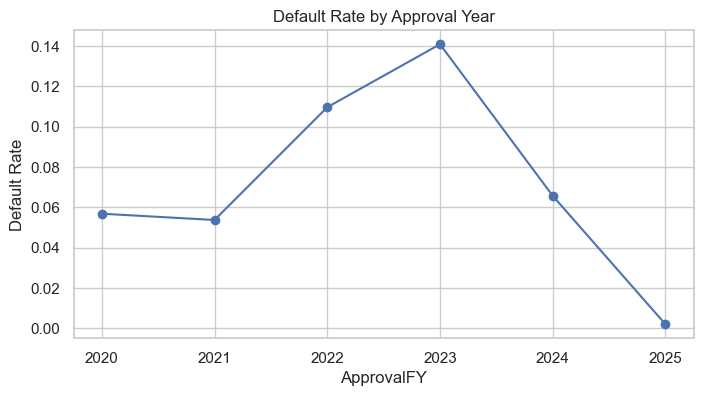

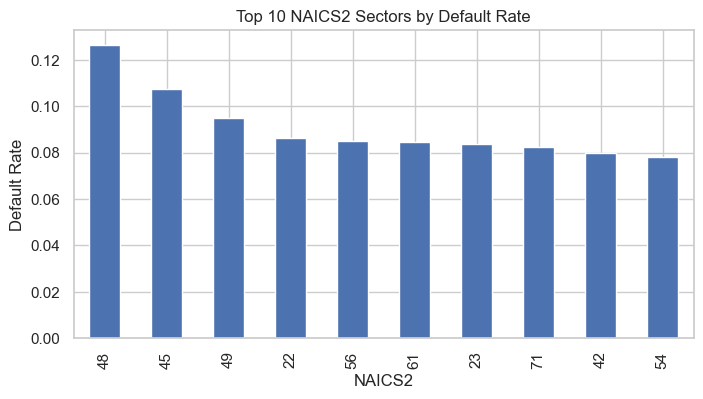

In [19]:
# 7.1 Default rate by approval year
default_by_year = df_model_clean.groupby("ApprovalFY")["LoanDefault"].mean().sort_index()

plt.figure(figsize=(8, 4))
default_by_year.plot(marker="o")
plt.title("Default Rate by Approval Year")
plt.xlabel("ApprovalFY")
plt.ylabel("Default Rate")
plt.grid(True)
plt.show()

# 7.2 Default rate by NAICS2 sector (top 10)
df_naics = df_model_clean.copy()
df_naics["NAICS2"] = df_naics["NAICS2"].astype(str).str.strip()

default_by_naics = (
    df_naics[df_naics["NAICS2"].str.match(r"^\d{2}$", na=False)]
    .groupby("NAICS2")["LoanDefault"].mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
default_by_naics.plot(kind="bar")
plt.title("Top 10 NAICS2 Sectors by Default Rate")
plt.xlabel("NAICS2")
plt.ylabel("Default Rate")
plt.grid(True, axis="y")
plt.show()

The exploratory analysis highlights two useful patterns.

First, default rates vary across approval years, suggesting that temporal and macroeconomic conditions may influence portfolio risk. The most recent approval year(s) should be interpreted cautiously due to right-censoring: recently approved loans have had less time to reach a charge-off outcome, and the supervised subset includes only finalized outcomes (PIF/CHGOFF).

Second, default rates differ substantially across industry sectors (`NAICS2`), indicating that sector-level business activity is an important risk signal.

These observations support the inclusion of both temporal features and industry-based categorical variables in the supervised modeling stage.

## 8. Evaluation Utilities

A unified evaluation function is used to ensure consistent reporting across models.
Because the dataset is imbalanced, multiple complementary metrics are reported (precision, recall, F1, ROC-AUC, and PR-AUC when probabilities are available).

In [22]:
def evaluate_classifier(name, y_true, y_pred, y_proba=None, verbose=True):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    out = {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": None,
        "pr_auc": None
    }

    if y_proba is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_proba)
        out["pr_auc"] = average_precision_score(y_true, y_proba)

    if verbose:
        print(f"=== {name} ===")
        print(f"Accuracy : {acc:.3f}")
        print(f"Precision: {prec:.3f}")
        print(f"Recall   : {rec:.3f}")
        print(f"F1-score : {f1:.3f}")

        if y_proba is not None:
            print(f"ROC-AUC  : {out['roc_auc']:.3f}")
            print(f"PR-AUC   : {out['pr_auc']:.3f}")

        print("\nClassification report:")
        print(classification_report(y_true, y_pred, zero_division=0))

    return out

results = []

## 8.1 Baseline Model (DummyClassifier)

Because the dataset is highly imbalanced, a naive baseline is reported to demonstrate why accuracy alone can be misleading.
The DummyClassifier predicts the majority class and serves as a minimal reference point.

In [24]:
dummy_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

dummy_pipe.fit(X_train, y_train)

y_pred_dummy = dummy_pipe.predict(X_test)
y_proba_dummy = dummy_pipe.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("Dummy (Most Frequent)", y_test, y_pred_dummy, y_proba_dummy))

=== Dummy (Most Frequent) ===
Accuracy : 0.926
Precision: 0.000
Recall   : 0.000
F1-score : 0.000
ROC-AUC  : 0.500
PR-AUC   : 0.074

Classification report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     10358
           1       0.00      0.00      0.00       833

    accuracy                           0.93     11191
   macro avg       0.46      0.50      0.48     11191
weighted avg       0.86      0.93      0.89     11191



## 9. Logistic Regression

Logistic Regression is used as a strong linear baseline classifier. To mitigate the strong class imbalance, `class_weight="balanced"` is applied so that misclassifying defaulted loans (the minority class) receives a higher penalty.

Hyperparameter tuning is performed over the regularization strength (`C`) using cross-validation. The model is selected using F1-score to balance precision and recall for the default class.

In [26]:
log_clf = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

log_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", log_clf)
])

grid_log = GridSearchCV(
    log_pipe,
    param_grid={"clf__C": [0.01, 0.1, 1.0, 10.0]},
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_log.fit(X_train, y_train)

print("Best parameters:", grid_log.best_params_)
print(f"Best CV F1: {grid_log.best_score_:.3f}")

y_pred = grid_log.predict(X_test)
y_proba = grid_log.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("Logistic Regression", y_test, y_pred, y_proba))

Best parameters: {'clf__C': 10.0}
Best CV F1: 0.378
=== Logistic Regression ===
Accuracy : 0.798
Precision: 0.246
Recall   : 0.833
F1-score : 0.380
ROC-AUC  : 0.878
PR-AUC   : 0.352

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     10358
           1       0.25      0.83      0.38       833

    accuracy                           0.80     11191
   macro avg       0.61      0.81      0.63     11191
weighted avg       0.93      0.80      0.84     11191



***Logistic Regression – Results***

Logistic Regression was trained with `class_weight = balanced` to explicitly address class imbalance, and tuned via GridSearchCV over the regularization strength `C`. The best configuration selected was `C = 10.0` (best CV F1 ≈ 0.378).

On the test set, the model achieved **high recall for the default class** (Recall = 0.833), indicating strong sensitivity and relatively few missed defaults. However, precision was low (Precision = 0.246), meaning many non-default loans were incorrectly flagged as defaults, which reduced overall classification quality (F1 = 0.380) and accuracy (Accuracy = 0.798).

Ranking performance was moderate (ROC-AUC = 0.878; PR-AUC = 0.352), suggesting the model provides some separation between defaults and non-defaults, but is limited compared with stronger non-linear models. Overall, Logistic Regression with class weighting is effective as a **high-recall screening baseline**, but its low precision implies a high false-alarm rate, making it less suitable as a final model when balanced precision–recall performance is required.

## 10. K-Nearest Neighbors (KNN)

KNN is a distance-based classifier that predicts the label of an observation using the majority vote (or distance-weighted vote) of its nearest neighbors in feature space. In strongly imbalanced datasets, neighbor composition is often dominated by the majority class, which can reduce sensitivity to the minority default class.

A small hyperparameter search is performed over the number of neighbors and the voting scheme. The model is selected using cross-validated F1-score to balance precision and recall for default prediction.

In [29]:
knn_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", KNeighborsClassifier())
])

grid_knn = GridSearchCV(
    knn_pipe,
    param_grid={
        "clf__n_neighbors": [3, 5, 7, 9],
        "clf__weights": ["uniform", "distance"]
    },
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_knn.fit(X_train, y_train)

print("Best parameters:", grid_knn.best_params_)
print(f"Best CV F1: {grid_knn.best_score_:.3f}")

y_pred = grid_knn.predict(X_test)
y_proba = grid_knn.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("KNN", y_test, y_pred, y_proba))

Best parameters: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Best CV F1: 0.296
=== KNN ===
Accuracy : 0.921
Precision: 0.441
Recall   : 0.235
F1-score : 0.307
ROC-AUC  : 0.700
PR-AUC   : 0.260

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     10358
           1       0.44      0.24      0.31       833

    accuracy                           0.92     11191
   macro avg       0.69      0.61      0.63     11191
weighted avg       0.90      0.92      0.91     11191



***K-Nearest Neighbors (KNN) – Results***

The tuned KNN model selected `n_neighbors = 3` with `weights = distance` (best CV F1 ≈ 0.296). On the test set, the model achieved high overall accuracy (Accuracy = 0.921), but this metric is misleading under strong class imbalance. Performance on the default class was weak (Recall = 0.235, F1 = 0.307), indicating that many defaults were missed.

Although precision for predicted defaults was moderate (Precision = 0.441), the low recall and modest minority-class ranking performance (PR-AUC = 0.260; ROC-AUC = 0.700) suggest that KNN strongly favors the majority class. This behavior is consistent with distance-based methods in imbalanced settings, where local neighborhoods are dominated by non-default observations.

Overall, KNN is not a competitive choice for risk-sensitive default screening compared with approaches that explicitly address imbalance (e.g., class weighting, resampling, or tree-based ensembles).

Next, tree-based models are evaluated, as they can capture non-linear relationships and interactions that are not modeled by linear classifiers and may improve minority-class performance.

## 11. Random Forest

Random Forest is an ensemble of decision trees that improves stability and captures non-linear relationships and feature interactions. To reduce bias toward the majority class under class imbalance, `class_weight="balanced"` is applied.

Hyperparameter tuning is performed over the number of trees, maximum depth, and the minimum samples required to split a node. The model is selected using cross-validated F1-score to balance precision and recall for the default class.

In [33]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=2
    ))
])

grid_rf = GridSearchCV(
    rf_pipe,
    param_grid={
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5]
    },
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print(f"Best CV F1: {grid_rf.best_score_:.3f}")

y_pred = grid_rf.predict(X_test)
y_proba = grid_rf.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("Random Forest", y_test, y_pred, y_proba))

Best parameters: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV F1: 0.726
=== Random Forest ===
Accuracy : 0.965
Precision: 0.860
Recall   : 0.634
F1-score : 0.730
ROC-AUC  : 0.969
PR-AUC   : 0.825

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     10358
           1       0.86      0.63      0.73       833

    accuracy                           0.97     11191
   macro avg       0.92      0.81      0.86     11191
weighted avg       0.96      0.97      0.96     11191



***Random Forest – Results***

A Random Forest classifier was trained within the shared preprocessing pipeline, using `class_weight = balanced` to mitigate class imbalance. Hyperparameters were tuned via GridSearchCV across the number of trees, maximum depth, and minimum split size. The best configuration selected was `n_estimators = 200`, `max_depth = None`, and `min_samples_split = 5` (best CV F1 ≈ 0.726).

On the test set, Random Forest achieved strong overall performance (Accuracy = 0.965) with **very high precision for the default class** (Precision = 0.860), indicating that when the model predicts a default, it is usually correct. However, recall was lower (Recall = 0.634), meaning a substantial portion of true defaults were not detected. This trade-off is reflected in the final F1-score (F1 = 0.730).

Ranking performance was excellent (ROC-AUC = 0.969; PR-AUC = 0.825), suggesting the model separates defaults from non-defaults well and provides useful risk ranking. Overall, Random Forest is a strong model for **high-precision default flagging and ranking**, but it may be less suitable when the primary goal is to maximize default capture (high recall) in a risk-sensitive screening context.ֿ

## 12. Gradient Boosting (Baseline)

Gradient Boosting is a powerful ensemble method that builds trees sequentially, where each new tree corrects errors made by the previous ones. This model is evaluated without resampling to provide a baseline comparison before introducing SMOTE.

Hyperparameter tuning is performed over the number of estimators, learning rate, and tree depth. The model is selected using cross-validated F1-score to balance precision and recall for the default class.

In [36]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

grid_gb = GridSearchCV(
    gb_pipe,
    param_grid={
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [3, 5]
    },
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_gb.fit(X_train, y_train)

print("Best parameters:", grid_gb.best_params_)
print(f"Best CV F1: {grid_gb.best_score_:.3f}")

y_pred = grid_gb.predict(X_test)
y_proba = grid_gb.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("Gradient Boosting (Baseline)", y_test, y_pred, y_proba))

Best parameters: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Best CV F1: 0.832
=== Gradient Boosting (Baseline) ===
Accuracy : 0.976
Precision: 0.868
Recall   : 0.801
F1-score : 0.833
ROC-AUC  : 0.979
PR-AUC   : 0.873

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     10358
           1       0.87      0.80      0.83       833

    accuracy                           0.98     11191
   macro avg       0.93      0.90      0.91     11191
weighted avg       0.98      0.98      0.98     11191



***Gradient Boosting (Baseline) – Results***

A Gradient Boosting classifier was trained within the shared preprocessing pipeline and tuned via GridSearchCV to maximize **F1** for the minority (default) class. The grid search evaluated combinations of the number of estimators, learning rate, and tree depth. The best configuration selected was `n_estimators = 200`, `learning_rate = 0.1`, and `max_depth = 5` (best CV F1 ≈ 0.832).

On the test set, the baseline Gradient Boosting model delivered the strongest overall performance among the non-resampled models, achieving **high precision and recall** for the default class (Precision = 0.868, Recall = 0.801) with the best F1-score (F1 = 0.833). Overall accuracy was also very high (Accuracy = 0.976).

In addition, ranking performance was excellent (ROC-AUC = 0.979; PR-AUC = 0.873), indicating strong separation between defaults and non-defaults and effective prioritization of high-risk loans. Overall, Gradient Boosting provides a robust balance between default detection quality (F1), minority-class coverage (recall), and ranking performance, making it a strong candidate for the final model.

## 13. Decision Tree

A Decision Tree is an interpretable model that learns a set of hierarchical if–then rules. While trees can capture non-linear relationships, they are more prone to overfitting compared with ensemble methods.

To mitigate the strong class imbalance, `class_weight="balanced"` is applied. Hyperparameter tuning is performed over tree depth and the minimum samples required to split a node. The model is selected using cross-validated F1-score to balance precision and recall for the default class.

In [39]:
dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

grid_dt = GridSearchCV(
    dt_pipe,
    param_grid={
        "clf__max_depth": [5, 10, 20, None],
        "clf__min_samples_split": [2, 5, 10]
    },
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_dt.fit(X_train, y_train)

print("Best parameters:", grid_dt.best_params_)
print(f"Best CV F1: {grid_dt.best_score_:.3f}")

y_pred = grid_dt.predict(X_test)
y_proba = grid_dt.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("Decision Tree", y_test, y_pred, y_proba))

Best parameters: {'clf__max_depth': 20, 'clf__min_samples_split': 2}
Best CV F1: 0.742
=== Decision Tree ===
Accuracy : 0.959
Precision: 0.692
Recall   : 0.800
F1-score : 0.742
ROC-AUC  : 0.887
PR-AUC   : 0.592

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     10358
           1       0.69      0.80      0.74       833

    accuracy                           0.96     11191
   macro avg       0.84      0.89      0.86     11191
weighted avg       0.96      0.96      0.96     11191



***Decision Tree – Results***

A Decision Tree classifier was trained within the shared preprocessing pipeline using `class_weight = balanced` to account for class imbalance. Hyperparameters were tuned via GridSearchCV over the maximum tree depth and the minimum number of samples required to split a node, optimizing **F1** for the minority (default) class. The best configuration selected was `max_depth = 20` and `min_samples_split = 2` (best CV F1 ≈ 0.742).

On the test set, the Decision Tree achieved relatively strong default detection (Recall = 0.800) with moderate precision (Precision = 0.692), resulting in an F1-score of 0.742 and overall accuracy of 0.959. This indicates the model captures many defaults but also produces a non-trivial number of false positives compared with the top-performing ensemble models.

However, ranking performance was substantially weaker (ROC-AUC = 0.887; PR-AUC = 0.592), suggesting limited ability to reliably prioritize true defaults above non-defaults across different thresholds. This is consistent with a single-tree model, which is prone to higher variance and less stable probability estimates than ensemble methods. Overall, the Decision Tree provides interpretable rules and reasonable recall, but it is less competitive as a final model due to weaker minority-class ranking quality compared with ensemble approaches.

## 14. Supervised Model Comparison (Baseline)

Baseline supervised models are compared using metrics that are appropriate under class imbalance.
F1-score summarizes the precision–recall trade-off for the default class, while ROC-AUC and PR-AUC reflect ranking performance (with PR-AUC being especially informative for the minority class).

Models are ranked primarily by F1-score, and ROC-AUC / PR-AUC are used as complementary indicators of discrimination and minority-class ranking quality.

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
4,Gradient Boosting (Baseline),0.976,0.868,0.801,0.833,0.979,0.873
5,Decision Tree,0.959,0.692,0.800,0.742,0.887,0.592
3,Random Forest,0.965,0.860,0.634,0.730,0.969,0.825
1,Logistic Regression,0.798,0.246,0.833,0.380,0.878,0.352
2,KNN,0.921,0.441,0.235,0.307,0.700,0.260
0,Dummy (Most Frequent),0.926,0.000,0.000,0.000,0.500,0.074


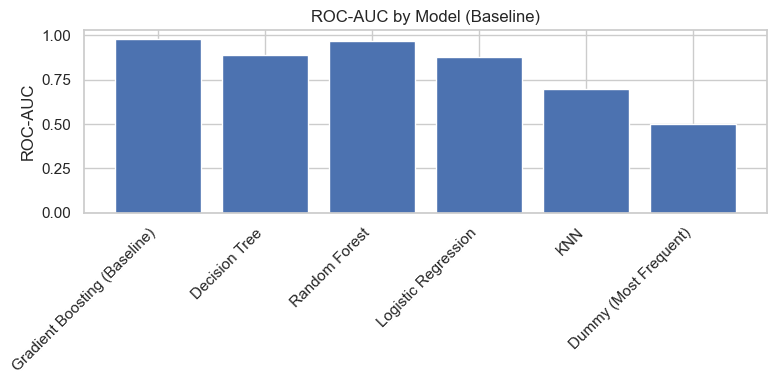

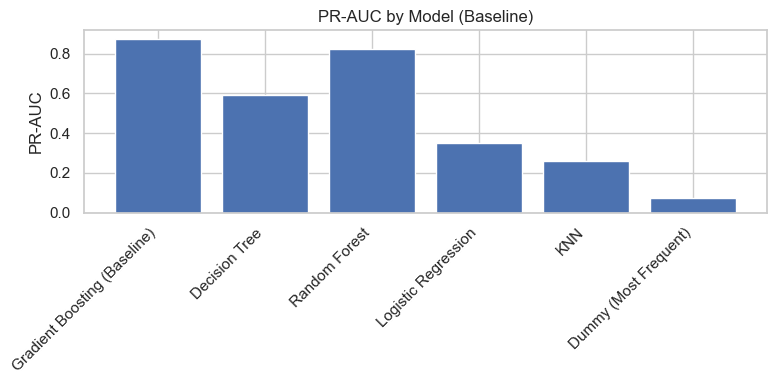

In [42]:
# Build comparison table
results_df = pd.DataFrame(results).drop_duplicates(subset="model").round(3)

# Sort by F1 (primary metric for imbalanced classification)
results_sorted = results_df.sort_values(by="f1", ascending=False)

display(results_sorted)

# Plot ROC-AUC by model (sorted by F1 for readability)
plt.figure(figsize=(8, 4))
plt.bar(results_sorted["model"], results_sorted["roc_auc"])
plt.xticks(rotation=45, ha="right")
plt.title("ROC-AUC by Model (Baseline)")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

# Plot PR-AUC by model (if available)
if "pr_auc" in results_sorted.columns and results_sorted["pr_auc"].notna().any():
    plt.figure(figsize=(8, 4))
    plt.bar(results_sorted["model"], results_sorted["pr_auc"])
    plt.xticks(rotation=45, ha="right")
    plt.title("PR-AUC by Model (Baseline)")
    plt.ylabel("PR-AUC")
    plt.tight_layout()
    plt.show()

***Model Comparison – Baseline Results***

The baseline comparison shows clear differences across models under class imbalance (default=1 is the minority class).  
Among the baselines, **Gradient Boosting (Baseline)** performs best overall (**F1 = 0.833**, **ROC‑AUC = 0.979**, **PR‑AUC = 0.873**), combining strong minority detection with excellent ranking quality.

**Random Forest** is highly precise (**Precision = 0.860**) but has lower sensitivity (**Recall = 0.634**), while the **Decision Tree** is weaker overall (**F1 = 0.742**, **PR‑AUC = 0.592**).  
**Logistic Regression** and **KNN** are notably less effective for risk‑sensitive screening due to much lower PR‑AUC / F1 on the default class.

Based on these results, Gradient Boosting is the strongest candidate for the final model, followed by a class‑balancing experiment (SMOTE) and threshold tuning.


## 15. Gradient Boosting + SMOTE (Imbalance Handling Experiment)

To explicitly address class imbalance, SMOTE is applied **inside an imblearn pipeline**.
This design ensures that oversampling is performed **only on the training folds** during cross-validation,
preventing information leakage into the test set and producing a more reliable evaluation.

In [45]:
gb_smote_pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

grid_gb_smote = GridSearchCV(
    gb_smote_pipe,
    param_grid={
        "clf__n_estimators": [200],
        "clf__learning_rate": [0.1],
        "clf__max_depth": [5]
    },
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_gb_smote.fit(X_train, y_train)

print("Best parameters:", grid_gb_smote.best_params_)
print(f"Best CV F1: {grid_gb_smote.best_score_:.3f}")

# Save final-model predictions with explicit names (avoids confusion later)
y_pred_gb_smote  = grid_gb_smote.predict(X_test)
y_proba_gb_smote = grid_gb_smote.predict_proba(X_test)[:, 1]

results.append(
    evaluate_classifier("Gradient Boosting + SMOTE", y_test, y_pred_gb_smote, y_proba_gb_smote)
)

/Users/rebeccaelhaj/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/rebeccaelhaj/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/rebeccaelhaj/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Best parameters: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Best CV F1: 0.822
=== Gradient Boosting + SMOTE ===
Accuracy : 0.973
Precision: 0.808
Recall   : 0.843
F1-score : 0.825
ROC-AUC  : 0.979
PR-AUC   : 0.878

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     10358
           1       0.81      0.84      0.82       833

    accuracy                           0.97     11191
   macro avg       0.90      0.91      0.91     11191
weighted avg       0.97      0.97      0.97     11191



***Gradient Boosting + SMOTE – Results***

To explicitly address the strong class imbalance, SMOTE oversampling was integrated into the modeling pipeline using an `imblearn` pipeline: preprocessing → SMOTE (applied on training folds only) → Gradient Boosting. This ensures that synthetic minority-class samples are generated **only from the training data**, preventing leakage into the test set. The model was tuned via 3-fold GridSearchCV to maximize **F1** for the default class. The best configuration matched the baseline Gradient Boosting settings: `n_estimators = 200`, `learning_rate = 0.1`, and `max_depth = 5` (best CV F1 ≈ 0.822).

On the held-out test set, the SMOTE-enhanced model achieved a strong overall balance with improved default detection:
- **Recall (default=1): 0.843**, indicating fewer missed defaults compared to the baseline model
- **Precision (default=1): 0.808**, reflecting a moderate increase in false positives relative to the baseline
- **F1 (default=1): 0.825**, only slightly below the baseline F1
- Excellent discrimination and minority-class retrieval: **ROC-AUC = 0.979**, **PR-AUC = 0.878** (the best PR-AUC among tested models)

**Interpretation:**  
SMOTE shifts the model toward higher sensitivity to defaults (higher recall) at the cost of some precision, which is the expected precision–recall trade-off when oversampling the minority class. Since credit-risk screening often prioritizes minimizing false negatives (missed defaults), the improved recall and best PR-AUC make **Gradient Boosting + SMOTE** a strong candidate for the final model.

**Implementation note:**  
SMOTE is applied after the preprocessing step, which includes one-hot encoding of categorical variables. In this setting, oversampling may create non-binary synthetic values in one-hot features. This approach is used here as a practical imbalance-handling experiment; alternative approaches include using **SMOTENC** for mixed feature types or relying on **class-weighted** ensemble methods.

## 16. Final Comparison (Including SMOTE)

All supervised models are compared after adding the SMOTE experiment. The final selection is based on imbalance-aware performance: F1-score (precision–recall balance) alongside recall and PR-AUC, since detecting defaults (minority class) is the primary risk-sensitive objective.

In [48]:
final_results_df = pd.DataFrame(results).drop_duplicates(subset="model").round(3)

# Rank primarily by F1-score (with recall as a secondary lens for default detection)
final_sorted = final_results_df.sort_values(by="f1", ascending=False)
display(final_sorted)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
4,Gradient Boosting (Baseline),0.976,0.868,0.801,0.833,0.979,0.873
6,Gradient Boosting + SMOTE,0.973,0.808,0.843,0.825,0.979,0.878
5,Decision Tree,0.959,0.692,0.800,0.742,0.887,0.592
3,Random Forest,0.965,0.860,0.634,0.730,0.969,0.825
1,Logistic Regression,0.798,0.246,0.833,0.380,0.878,0.352
2,KNN,0.921,0.441,0.235,0.307,0.700,0.260
0,Dummy (Most Frequent),0.926,0.000,0.000,0.000,0.500,0.074


## Final Model Comparison and Selection

The final comparison shows that the two Gradient Boosting variants achieve the strongest overall performance under class imbalance. The baseline Gradient Boosting model attains the highest F1-score (**F1 = 0.833**) with strong precision and recall (**Precision = 0.868**, **Recall = 0.801**) and excellent discrimination ability (**ROC-AUC = 0.979**, **PR-AUC = 0.873**).

The Gradient Boosting + SMOTE model yields a slightly lower F1-score (**F1 = 0.825**) due to reduced precision (**Precision = 0.808**), but it improves minority-class detection with higher recall (**Recall = 0.843**) and achieves the best Precision–Recall AUC (**PR-AUC = 0.878**). Because PR-AUC focuses on performance for the minority class, this indicates improved **minority-class retrieval** (i.e., identifying more true defaults among the top-risk predictions), reflecting the expected precision–recall trade-off introduced by oversampling.

Both Gradient Boosting variants have the same ROC-AUC (**0.979**), so the final choice is driven primarily by the precision–recall trade-off and PR-AUC rather than overall ranking alone. Random Forest and Decision Tree provide reasonable performance but are weaker than Gradient Boosting overall: Random Forest exhibits high precision (**0.860**) and strong PR-AUC (**0.825**) but lower recall (**0.634**), while the Decision Tree achieves relatively high recall (**0.800**) yet substantially lower PR-AUC (**0.592**), indicating poorer minority-class separation. Logistic Regression and KNN show the weakest F1 and PR-AUC, confirming limited effectiveness for default detection in this setting.

**Final selection rationale:**  
If the objective is risk-sensitive screening where missing defaults (false negatives) is more costly, the SMOTE-enhanced Gradient Boosting model is attractive due to its higher recall and best PR-AUC. However, if the objective is robust balanced performance with the highest F1 and stronger precision (fewer false alarms), the baseline Gradient Boosting model is preferred.

In this project, the baseline **Gradient Boosting (Baseline)** model is selected as the final supervised model because it achieved the **highest F1-score** and **highest precision** while maintaining excellent ranking performance (ROC-AUC and PR-AUC). The SMOTE variant improved recall and slightly increased PR-AUC, but at the cost of lower precision and a slightly lower F1.

## 17. Confusion Matrix (Final Model)

A confusion matrix is presented for the selected final model (Gradient Boosting (Baseline))
to summarize false positives and false negatives in a credit-risk setting.

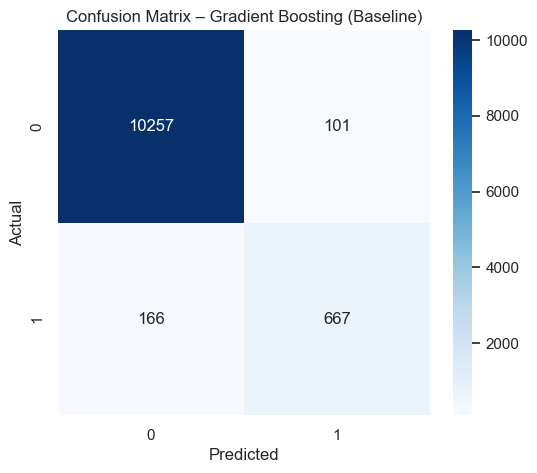

In [51]:
# Use the selected final model: Gradient Boosting (Baseline)
final_pipe = grid_gb.best_estimator_

# Final-model predictions on the test set
y_pred_final  = final_pipe.predict(X_test)
y_proba_final = final_pipe.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Gradient Boosting (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

***Confusion Matrix Interpretation – Gradient Boosting (Baseline)***

The confusion matrix provides a concrete breakdown of the final model’s decisions on the test set (TN/FP/FN/TP as shown in the matrix above).

**Interpretation:**  
The baseline Gradient Boosting model achieves strong default-detection performance while keeping false alarms relatively low. In a credit-risk setting, **false negatives** (missed defaults) are typically more costly than **false positives** (additional reviews), so this confusion-matrix view complements threshold-free metrics such as ROC-AUC and PR-AUC by showing the operational impact at the default decision threshold.


## 18. ROC Curve (Final Model)

The ROC curve visualizes the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR)
across all possible classification thresholds for the selected final model.

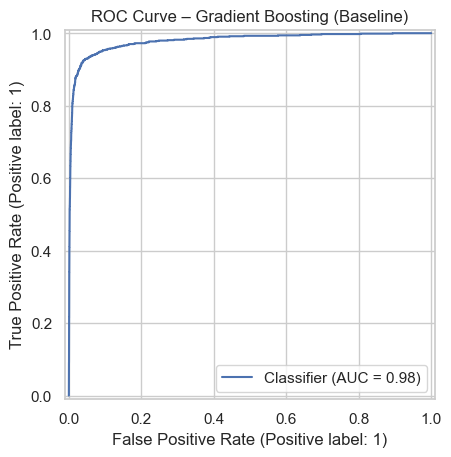

In [54]:
RocCurveDisplay.from_predictions(y_test, y_proba_final)
plt.title("ROC Curve – Gradient Boosting (Baseline)")
plt.show()

***ROC Curve Analysis – Gradient Boosting (Baseline)***

The ROC curve summarizes the trade‑off between true‑positive rate and false‑positive rate across all thresholds.  
For the final model, **ROC‑AUC = 0.979**, indicating excellent discriminative ability.

Because defaults are the minority class, ROC‑AUC is complemented with PR‑AUC and threshold‑based analysis (next section) to better reflect operational performance under class imbalance.


## 18.1 Precision–Recall Curve (Final Model)

Since default is the minority class, the Precision–Recall (PR) curve is often more informative than ROC.
It highlights the trade-off between capturing defaults (recall) and avoiding false alarms (precision).

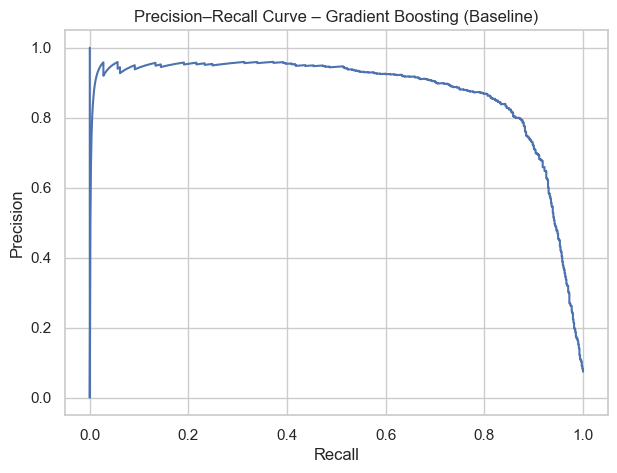

Test PR-AUC (Average Precision): 0.8729


In [57]:
prec, rec, _ = precision_recall_curve(y_test, y_proba_final)

plt.figure(figsize=(7, 5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Gradient Boosting (Baseline)")
plt.grid(True)
plt.show()

print("Test PR-AUC (Average Precision):", round(average_precision_score(y_test, y_proba_final), 4))

## 18.2 Threshold Selection (Cross-Validated on Train)

To avoid tuning the decision threshold on the test set, out-of-fold probability estimates are generated on the training data.
The threshold that maximizes **F1 on CV-train** is selected and then applied **once** to the held-out test set.

**Selected threshold (max F1 on CV-train): 0.44**

At this threshold, the test performance for the default class (1) is approximately:
- **Precision:** 0.85  
- **Recall:** 0.82  
- **F1:** 0.84  

This step demonstrates how the operating point can be adjusted depending on the objective (e.g., higher recall to minimize missed defaults, or higher precision to reduce false alarms).

,threshold,precision,recall,f1
39,0.44,0.844417,0.831231,0.837772
36,0.41,0.837133,0.838138,0.837635
38,0.43,0.841467,0.833634,0.837532
37,0.42,0.838758,0.835736,0.837244
35,0.40,0.833581,0.840841,0.837195
33,0.38,0.826737,0.846847,0.836671
41,0.46,0.849752,0.823724,0.836536
34,0.39,0.829592,0.843544,0.836510
40,0.45,0.846936,0.825826,0.836248
31,0.36,0.819493,0.853453,0.836128


Selected threshold (max F1 on CV-train): 0.44

Test metrics at tuned threshold:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10358
           1       0.85      0.82      0.84       833

    accuracy                           0.98     11191
   macro avg       0.92      0.90      0.91     11191
weighted avg       0.98      0.98      0.98     11191



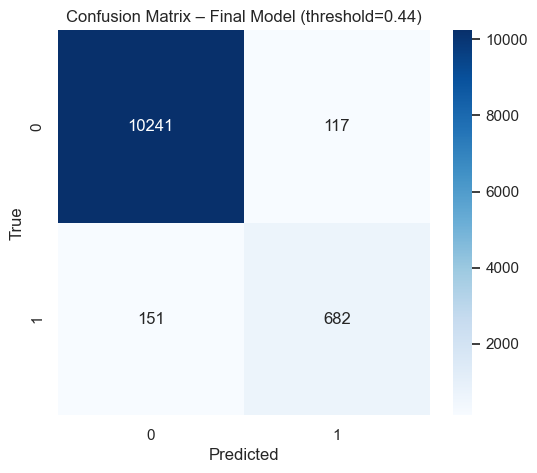

In [59]:
best_pipe = grid_gb.best_estimator_

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
oof_proba = cross_val_predict(
    best_pipe, X_train, y_train,
    cv=cv, method="predict_proba", n_jobs=2
)[:, 1]

thresholds = np.linspace(0.05, 0.95, 91)
rows = []

for t in thresholds:
    y_hat = (oof_proba >= t).astype(int)
    rows.append({
        "threshold": float(t),
        "precision": precision_score(y_train, y_hat, zero_division=0),
        "recall": recall_score(y_train, y_hat, zero_division=0),
        "f1": f1_score(y_train, y_hat, zero_division=0)
    })

thr_df = pd.DataFrame(rows)
best_t = float(thr_df.loc[thr_df["f1"].idxmax(), "threshold"])

display(thr_df.sort_values("f1", ascending=False).head(10))
print("Selected threshold (max F1 on CV-train):", round(best_t, 3))

# Apply once on test
y_pred_thresh = (y_proba_final >= best_t).astype(int)

print("\nTest metrics at tuned threshold:")
print(classification_report(y_test, y_pred_thresh, zero_division=0))

cm_t = confusion_matrix(y_test, y_pred_thresh)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_t, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix – Final Model (threshold={best_t:.2f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## 19. Feature Importance (Final Model)

To improve interpretability, feature importances are extracted from the final selected model (Gradient Boosting (Baseline)). For tree-based models, feature importance reflects how much each feature contributes to reducing impurity across the ensemble, providing a global view of which variables most strongly influence predictions.

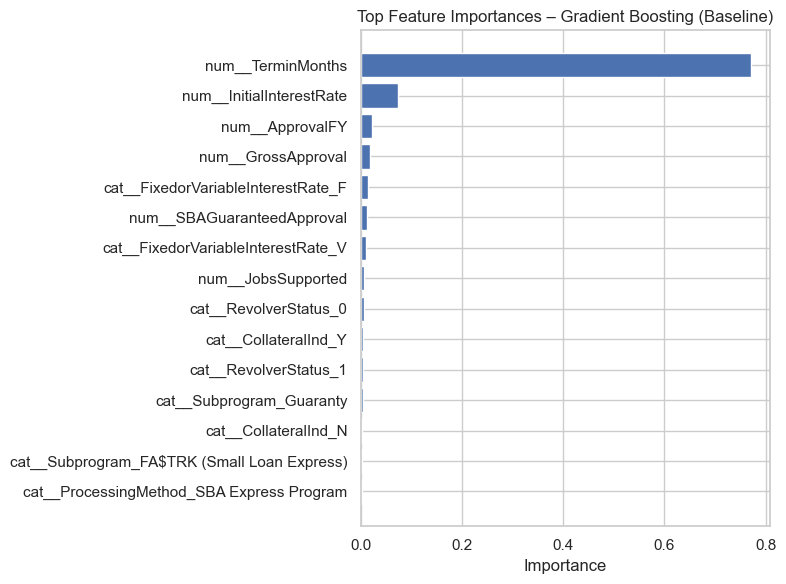

In [61]:
best_pipe = grid_gb.best_estimator_

gb_model = best_pipe.named_steps["clf"]
preproc = best_pipe.named_steps["preprocessor"]

# Get feature names after preprocessing (including one-hot encoded categories)
feature_names = preproc.get_feature_names_out()

# Tree-based feature importances
importances = gb_model.feature_importances_

# Plot top N most important features
top_n = 15
idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(8, 6))
plt.barh(feature_names[idx][::-1], importances[idx][::-1])
plt.title("Top Feature Importances – Gradient Boosting (Baseline)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Feature Importance Analysis – Gradient Boosting (Baseline)

The feature importance results provide a global explanation of which variables most strongly drive the final model’s default-risk predictions.

The most influential feature by a large margin is **loan term length (`TerminMonths`)**, indicating that repayment horizon is the dominant risk driver in this dataset. Longer terms typically increase exposure to uncertainty in business performance and macroeconomic conditions, which can elevate default risk.

The **initial interest rate (`InitialInterestRate`)** is the second most important feature, consistent with risk-based pricing: higher rates are often assigned to riskier borrowers and therefore carry strong predictive signal. The model also assigns meaningful importance to **interest-rate type indicators** (fixed vs. variable), suggesting that contract structure contributes additional risk information beyond the rate level alone.

Temporal and exposure-related variables also appear among the top contributors, including **approval year (`ApprovalFY`)** and loan size measures such as **`GrossApproval`** and **`SBAGuaranteedApproval`**, which reflect the timing of origination and the magnitude of financial exposure.

Finally, several categorical indicators related to **industry sector (`NAICS2`)**, **business age**, **revolver status**, and **project state** appear with smaller importances. This pattern suggests that, in this portfolio, **loan structure, pricing, and term characteristics** are more informative for default prediction than sector/location attributes alone.

Overall, the importance profile is economically plausible and supports interpretability: the model’s predictions are primarily driven by meaningful lending terms and pricing features rather than arbitrary noise.

## 20. Unsupervised Learning: K-Means Clustering

To complement the supervised default-prediction models, K-Means clustering is applied to identify interpretable loan/borrower “profiles” without using the target label. The analysis is performed on a random sample of 20,000 loans to keep runtime reasonable.

Clustering is based on a small numeric feature set that captures core loan structure and exposure:
**GrossApproval, InitialInterestRate, TerminMonths, and JobsSupported**. All features are standardized prior to clustering to ensure that differences in scale do not dominate distance computations.

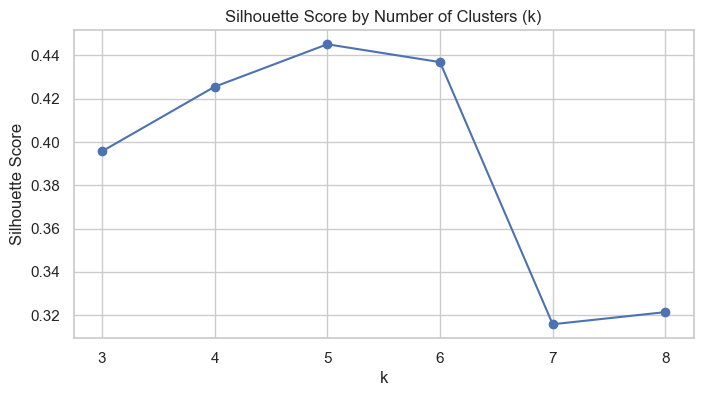

Selected k: 5


,count,avg_gross,avg_rate,avg_term,avg_jobs,default_rate
cluster,,,,,,
0,1055,3487894.79,5.58,231.44,19.43,0.01
1,11371,263876.67,5.91,95.70,8.45,0.06
2,2500,938912.92,5.71,292.26,9.55,0.00
3,478,1259014.85,6.21,128.71,103.68,0.01
4,4596,145905.77,10.49,100.17,5.75,0.15


In [64]:
cluster_features = ["GrossApproval", "InitialInterestRate", "TerminMonths", "JobsSupported"]

# Sample for computational efficiency
df_sample = df_model_clean.sample(n=20000, random_state=RANDOM_STATE)
X_cluster = df_sample[cluster_features].copy()

# Standardize features (required for distance-based clustering)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Choose k using silhouette score
candidate_ks = [3, 4, 5, 6, 7, 8]
silhouette_scores = []

for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(candidate_ks, silhouette_scores, marker="o")
plt.title("Silhouette Score by Number of Clusters (k)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

k_opt = candidate_ks[int(np.argmax(silhouette_scores))]
print("Selected k:", k_opt)

# Fit final K-Means and attach cluster labels
kmeans = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
df_sample["cluster"] = kmeans.fit_predict(X_cluster_scaled)

# Cluster summary table (default rate is reported for interpretation only)
cluster_profile = (
    df_sample.groupby("cluster")
    .agg(
        count=("LoanDefault", "size"),
        avg_gross=("GrossApproval", "mean"),
        avg_rate=("InitialInterestRate", "mean"),
        avg_term=("TerminMonths", "mean"),
        avg_jobs=("JobsSupported", "mean"),
        default_rate=("LoanDefault", "mean")
    )
    .round(2)
)

cluster_profile

#### Unsupervised Learning – K-Means Clustering Analysis

To explore structural patterns in the loan portfolio beyond supervised prediction, K‑Means clustering was applied to a random sample of **20,000** loans using four standardized numeric features: **GrossApproval**, **InitialInterestRate**, **TerminMonths**, and **JobsSupported**. Standardization ensures that variables measured on different scales contribute comparably to distance calculations.

##### Selection of the Number of Clusters (k)

The number of clusters was selected using the **Silhouette Score** over candidate values **k ∈ {3,4,5,6,7,8}**.  
The silhouette curve peaks at **k = 5**, therefore **five clusters** were selected for interpretation.

##### Cluster Profiles and Interpretation (k = 5)

The clusters represent distinct loan profiles (default rate is reported **post hoc** for interpretation only):

- **Cluster 0 – Very large approvals, long terms, low default**  
  n=1,055 | avg_gross ≈ $3.49M | avg_term ≈ 231 months | avg_rate ≈ 5.58% | default_rate ≈ 1%

- **Cluster 1 – Mainstream loans, moderate terms, moderate risk**  
  n=11,371 | avg_gross ≈ $264K | avg_term ≈ 96 months | avg_rate ≈ 5.91% | default_rate ≈ 6%

- **Cluster 2 – Large approvals with very long terms, near-zero default in this sample**  
  n=2,500 | avg_gross ≈ $0.94M | avg_term ≈ 292 months | avg_rate ≈ 5.71% | default_rate ≈ 0%  
  *(Note: “0.00” reflects rounding on the sample; this should be interpreted cautiously.)*

- **Cluster 3 – High jobs-supported / employment-impact loans, low default**  
  n=478 | avg_gross ≈ $1.26M | avg_jobs ≈ 104 | avg_rate ≈ 6.21% | default_rate ≈ 1%

- **Cluster 4 – Smaller approvals, high interest rates, highest default**  
  n=4,596 | avg_gross ≈ $146K | avg_rate ≈ 10.49% | avg_term ≈ 100 months | default_rate ≈ 15%

##### Summary

Overall, the clustering reveals meaningful portfolio segments that differ in loan size, pricing, term structure, and employment impact. In particular, the high‑rate small‑loan segment (Cluster 4) exhibits substantially higher observed default, complementing the supervised modeling insights with an interpretable segmentation view.


## 21. Cluster Visualization

To visually validate the clustering structure, a boxplot is used to compare the distribution of **GrossApproval** across the three K-Means clusters. This plot highlights differences in central tendency, variability, and the presence of extreme values (outliers) for each segment.

### 21.1 PCA Projection of Clusters (Visualization)

A 2D PCA projection is used to visualize the cluster separation in a compact space (for illustration only).


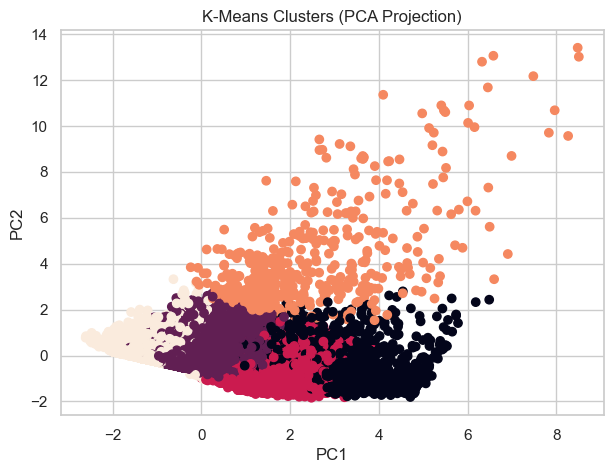

In [68]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_sample["cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA Projection)")
plt.grid(True)
plt.show()

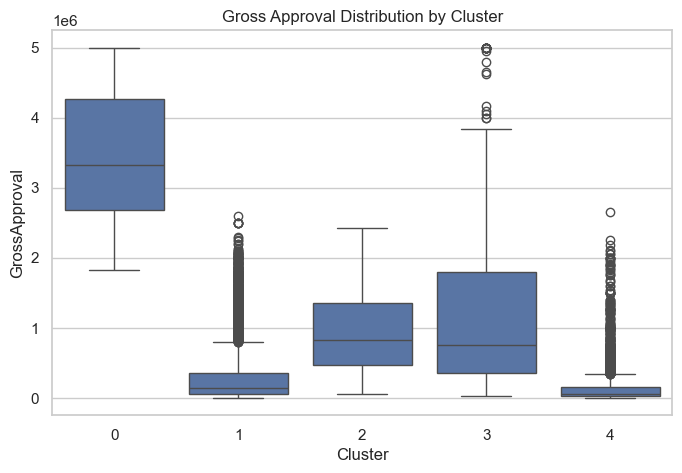

In [69]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_sample, x="cluster", y="GrossApproval")
plt.title("Gross Approval Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("GrossApproval")
plt.show()

#### Gross Approval Amount by Cluster – Distribution Analysis

The boxplot shows clear differences in **GrossApproval** across the five clusters, reinforcing that approval amount is a key dimension separating portfolio segments.

- **Cluster 4** and **Cluster 1** concentrate on smaller approvals (Cluster 4 is also characterized by much higher interest rates and the highest observed default).
- **Cluster 0** contains the highest approval amounts (high‑exposure loans), with long terms and low observed default.
- **Clusters 2 and 3** are intermediate/high‑approval segments; Cluster 3 stands out primarily by very high **JobsSupported**.

##### Interpretation

GrossApproval contributes strongly to the portfolio structure, but it should be interpreted jointly with pricing and term length. The combination of **smaller approvals with high interest rates** (Cluster 4) aligns with the higher observed default rate in that segment.


## Conclusion

This project developed and evaluated an end-to-end machine learning pipeline for SBA 7(a) loan default prediction under substantial class imbalance. Among the tested classifiers, the two Gradient Boosting variants achieved the strongest overall performance. The baseline Gradient Boosting model produced the highest F1-score with very strong precision and recall, while the SMOTE variant increased recall and slightly improved PR-AUC at the cost of lower precision.

**Final supervised model:** **Gradient Boosting (Baseline)** is selected as the final model because it achieved the **best overall balance** on the held-out test set (highest F1 and strongest precision) while maintaining excellent ranking performance (ROC-AUC and PR-AUC). The SMOTE-enhanced model remains a valuable alternative when maximizing recall is the dominant objective, but the baseline model is preferred here as the most robust and clean solution.

Model interpretability further supports the predictive results: feature-importance analysis highlights economically meaningful variables—most notably **loan term length** and **interest-rate related features**—as primary drivers of default risk. In addition, the clustering analysis reveals distinct loan segments with different financial profiles and observed default rates, providing a complementary portfolio-level view beyond individual predictions.

Overall, the combined supervised and unsupervised analyses deliver both robust predictive performance and actionable business insight for SBA 7(a) loan default risk assessment.

---

### GenAI Disclosure

<span style="color:red"><b>GenAI-assisted work:</b></span> ChatGPT was used to assist with **drafting parts of the narrative text** and **writing/refactoring selected code snippets** (e.g., utilities, organization, and phrasing). All preprocessing, modeling choices, experiments, and reported results were **executed, verified, and validated by the author**, who takes full responsibility for the final content.